<a href="https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/02.circuits-and-encoding/03.ansatz-and-parameterized-circuits/day17_01_02_parameter_binding_state_analysis_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Day17 parameter binding과 state 분석 실습

- Source: Google Drive `Day17/1-2.py`
- Runtime: Google Colab recommended. Do not install or execute dependencies locally for sync validation.


STEP 2. Parameterized Circuit 생성

        ┌───────┐ ░ ┌─┐
     q: ┤ Ry(θ) ├─░─┤M├
        └───────┘ ░ └╥┘
meas: 1/═════════════╩═
                     0 

Parameter
ParameterView([Parameter(θ)])

STEP 3. Parameter 후보 생성

Parameter List

0.0000
0.7854
1.5708
2.3562
3.1416
3.9270
4.7124
5.4978
6.2832

STEP 4. Parameter Binding

Theta = 0.0000

        ┌───────┐ ░ ┌─┐
     q: ┤ Ry(0) ├─░─┤M├
        └───────┘ ░ └╥┘
meas: 1/═════════════╩═
                     0 

Theta = 0.7854

        ┌─────────┐ ░ ┌─┐
     q: ┤ Ry(π/4) ├─░─┤M├
        └─────────┘ ░ └╥┘
meas: 1/═══════════════╩═
                       0 

Theta = 1.5708

        ┌─────────┐ ░ ┌─┐
     q: ┤ Ry(π/2) ├─░─┤M├
        └─────────┘ ░ └╥┘
meas: 1/═══════════════╩═
                       0 

Theta = 2.3562

        ┌──────────┐ ░ ┌─┐
     q: ┤ Ry(3π/4) ├─░─┤M├
        └──────────┘ ░ └╥┘
meas: 1/════════════════╩═
                        0 

Theta = 3.1416

        ┌───────┐ ░ ┌─┐
     q: ┤ Ry(π) ├─░─┤M├
        └───────┘ ░ └╥┘
m


Measurement

------------------------------------------------------------
Theta = 0.0000

{'0': 2048}

------------------------------------------------------------
Theta = 0.7854

{'1': 288, '0': 1760}

------------------------------------------------------------
Theta = 1.5708

{'1': 1009, '0': 1039}

------------------------------------------------------------
Theta = 2.3562

{'0': 289, '1': 1759}

------------------------------------------------------------
Theta = 3.1416

{'1': 2048}

------------------------------------------------------------
Theta = 3.9270

{'1': 1737, '0': 311}

------------------------------------------------------------
Theta = 4.7124

{'0': 961, '1': 1087}

------------------------------------------------------------
Theta = 5.4978

{'1': 314, '0': 1734}

------------------------------------------------------------
Theta = 6.2832

{'0': 2048}

STEP 7. Histogram 비교

Theta = 0.0000

Theta = 0.7854

Theta = 1.5708

Theta = 2.3562

Theta = 3.1416

Theta = 3.927


Theta = 5.4978

Theta = 6.2832

STEP 8. Probability 그래프


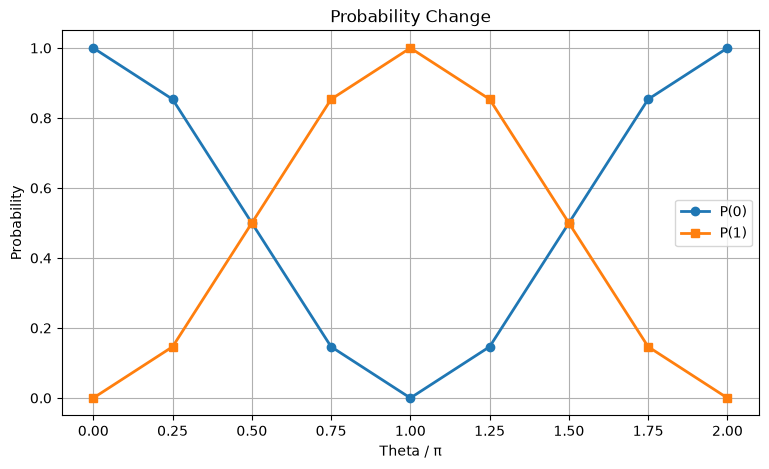


STEP 9. Quantum State 변화 분석

------------------------------------------------------------
Theta = 0.0000

Statevector([1.+0.j, 0.+0.j],
            dims=(2,))

P(0)=1.0000
P(1)=0.0000

|0> 방향

------------------------------------------------------------
Theta = 0.7854

Statevector([0.92387953+0.j, 0.38268343+0.j],
            dims=(2,))

P(0)=0.8536
P(1)=0.1464

|0> 방향

------------------------------------------------------------
Theta = 1.5708

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))

P(0)=0.5000
P(1)=0.5000

Superposition

------------------------------------------------------------
Theta = 2.3562

Statevector([0.38268343+0.j, 0.92387953+0.j],
            dims=(2,))

P(0)=0.1464
P(1)=0.8536

|1> 방향

------------------------------------------------------------
Theta = 3.1416

Statevector([6.123234e-17+0.j, 1.000000e+00+0.j],
            dims=(2,))

P(0)=0.0000
P(1)=1.0000

|1> 방향

------------------------------------------------------------
Theta = 3.9270

In [1]:
"""
===========================================================
Parameter 변화 실험 (Part 1)

STEP 1. 실습 환경 준비
STEP 2. Parameterized Circuit 생성
STEP 3. Parameter 후보 생성
STEP 4. Parameter Binding
STEP 5. Quantum State 분석
STEP 6. Quantum Circuit 실행
===========================================================
"""

import numpy as np
import pandas as pd

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

from qiskit.quantum_info import Statevector

from qiskit import transpile

from qiskit.visualization import plot_histogram

import matplotlib.pyplot as plt

try:

    from qiskit_aer import AerSimulator

    simulator = AerSimulator()

    AER_AVAILABLE = True

except:

    AER_AVAILABLE = False

print("=" * 70)
print("STEP 2. Parameterized Circuit 생성")
print("=" * 70)

theta = Parameter("θ")

qc = QuantumCircuit(1)

qc.ry(theta,0)

qc.measure_all()

print()

print(qc.draw())

print()

print("Parameter")

print(qc.parameters)

print()

print("="*70)

print("STEP 3. Parameter 후보 생성")

print("="*70)

theta_list = np.linspace(

    0,

    2*np.pi,

    9

)

print()

print("Parameter List")

print()

for theta_value in theta_list:

    print(f"{theta_value:.4f}")

print()

print("="*70)

print("STEP 4. Parameter Binding")

print("="*70)

circuits=[]

for theta_value in theta_list:

    bound = qc.assign_parameters(

        {

            theta:theta_value

        }

    )

    circuits.append(bound)

    print()

    print(f"Theta = {theta_value:.4f}")

    print()

    print(bound.draw())


print()

print("="*70)

print("STEP 5. Quantum State 분석")

print("="*70)

state_circuit = QuantumCircuit(1)

state_circuit.ry(theta,0)

state_list=[]

for theta_value in theta_list:

    bound = state_circuit.assign_parameters(

        {

            theta:theta_value

        }

    )

    state = Statevector.from_instruction(bound)

    state_list.append(state)

    print()

    print("-"*60)

    print(f"Theta = {theta_value:.4f}")

    print()

    print(state)

print()

print("="*70)

print("Probability")

print("="*70)

probability=[]

for state in state_list:

    prob = state.probabilities()

    probability.append(prob)

table=[]

for theta_value,prob in zip(

        theta_list,

        probability

):

    table.append(

        [

            theta_value,

            prob[0],

            prob[1]

        ]

    )

df = pd.DataFrame(

    table,

    columns=[

        "Theta",

        "P(0)",

        "P(1)"

    ]

)

print()

print(df)

print()

print("="*70)

print("STEP 6. Quantum Circuit 실행")

print("="*70)

results=[]

if AER_AVAILABLE:

    for circuit in circuits:

        compiled = transpile(

            circuit,

            simulator

        )

        result = simulator.run(

            compiled,

            shots=2048

        ).result()

        counts = result.get_counts()

        results.append(counts)

else:

    print()

    print("Aer Simulator가 없습니다.")

print()

print("="*70)

print("Measurement")

print("="*70)

for theta_value,count in zip(

        theta_list,

        results

):

    print()

    print("-"*60)

    print(f"Theta = {theta_value:.4f}")

    print()

    print(count)

"""
===========================================================
Parameter 변화 실험 (Part 2)

STEP 7. Histogram 비교
STEP 8. Probability 그래프
STEP 9. Quantum State 변화 분석
STEP 10. Prediction 생성
STEP 11. Machine Learning 연결
STEP 12. Quantum Learning Cycle
STEP 13. 결과 분석
STEP 14. 토론

===========================================================
"""

print()

print("="*70)

print("STEP 7. Histogram 비교")

print("="*70)

if AER_AVAILABLE:

    for theta_value,count in zip(

            theta_list,

            results

    ):

        print()

        print(f"Theta = {theta_value:.4f}")

        plot_histogram(

            count,

            title=f"Theta = {theta_value:.2f}"

        )

        plt.show()

else:

    print()

    print("Aer Simulator가 없습니다.")


print()

print("="*70)

print("STEP 8. Probability 그래프")

print("="*70)

angles = theta_list / np.pi

p0=[]

p1=[]

for value in probability:

    p0.append(value[0])

    p1.append(value[1])

plt.figure(figsize=(9,5))

plt.plot(

    angles,

    p0,

    marker="o",

    linewidth=2,

    label="P(0)"

)

plt.plot(

    angles,

    p1,

    marker="s",

    linewidth=2,

    label="P(1)"

)

plt.xlabel("Theta / π")

plt.ylabel("Probability")

plt.title("Probability Change")

plt.grid(True)

plt.legend()

plt.show()


print()

print("="*70)

print("STEP 9. Quantum State 변화 분석")

print("="*70)

for theta_value,state in zip(

        theta_list,

        state_list

):

    probs = state.probabilities()

    print()

    print("-"*60)

    print(f"Theta = {theta_value:.4f}")

    print()

    print(state)

    print()

    print(

        f"P(0)={probs[0]:.4f}"

    )

    print(

        f"P(1)={probs[1]:.4f}"

    )

    if np.isclose(probs[0], probs[1]):

        print()

        print("Superposition")

    elif probs[0]>probs[1]:

        print()

        print("|0> 방향")

    else:

        print()

        print("|1> 방향")

print()

print("=" * 70)

print("STEP 10. Prediction")

print("=" * 70)

prediction = []

for theta_value, prob in zip(

        theta_list,

        probability

):

    if prob[1] > 0.5:

        pred = "Class 1"

    elif prob[1] < 0.5:

        pred = "Class 0"

    else:

        pred = "Boundary"

    prediction.append(

        [

            theta_value,

            prob[0],

            prob[1],

            pred

        ]

    )

prediction_df = pd.DataFrame(

    prediction,

    columns=[

        "Theta",

        "P(0)",

        "P(1)",

        "Prediction"

    ]

)

print()

print(prediction_df)


print()

print("="*70)

print("STEP 11. Machine Learning 연결")

print("="*70)

print()

print("Classical Machine Learning")

print()

print("Weight")

print("↓")

print("Prediction")

print()

print("Quantum Machine Learning")

print()

print("Parameter θ")

print("↓")

print("Quantum State")

print("↓")

print("Measurement")

print("↓")

print("Prediction")



print()

print("="*70)

print("STEP 12. Learning Cycle")

print("="*70)

print()

print("Parameter")

print("↓")

print("Quantum State")

print("↓")

print("Measurement")

print("↓")

print("Prediction")

print("↓")

print("Loss")

print("↓")

print("Optimizer")

print("↓")

print("Parameter Update")

print()

print("="*70)
